**Digital Communication Simulation (BPSK)**

Goal:

Simulate a simple digital communication system using BPSK (Binary Phase Shift Keying).
This project shows knowledge in communications, modulation, noise, and signal detection.


Problem This Project Solves

In real communication systems, data is sent as signals.
Noise in the channel can change the signal and cause errors.
This project shows how BPSK modulation works and how noise can affect bit detection.
It also shows how to calculate Bit Error Rate (BER) with different noise levels.

What I Did
Generated random binary data (0s and 1s).
Mapped 0 → -1 and 1 → +1 using BPSK modulation.
Added Gaussian noise to simulate a noisy channel.
Plotted original BPSK signal and noisy received signal.
Demodulated the received signal using simple threshold detection.
Calculated number of bit errors.
Plotted Bit Error Rate (BER) vs noise level to show effect of noise.
Tools and Libraries Used
Python 3
numpy – for random data generation and calculations
matplotlib – for plotting signals and BER
scipy – basic signal processing functions
IPython.display.Audio – (optional for audio simulation)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from IPython.display import Audio

In [2]:
# Number of bits
N = 100

# Random binary data
data = np.random.randint(0, 2, N)
print("Random data:", data)

Random data: [0 1 0 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 1 0 0 1 0 0 1 1 0 1 0 0 1 0 1 0 1 1 1
 0 0 0 1 1 1 1 0 1 0 0 1 0 0 1 0 1 0 0 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1
 0 0 1 0 1 0 1 1 1 1 0 1 1 0 1 1 0 1 1 0 1 0 1 0 0 1]


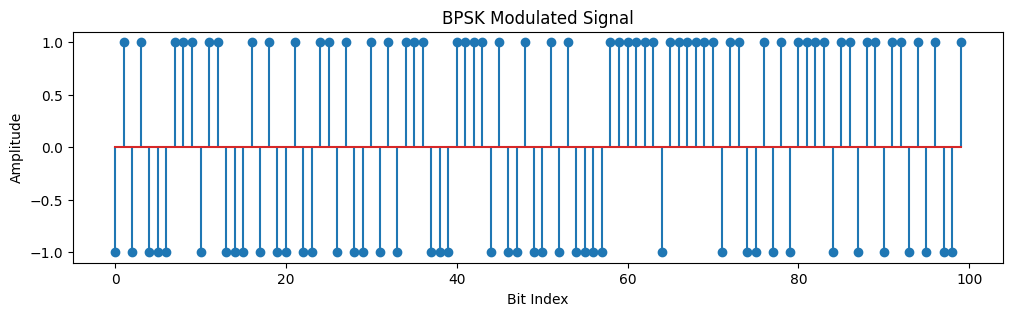

In [4]:
# Map 0 to -1 and 1 to +1
bpsk_signal = 2*data - 1

# Plot BPSK signal
plt.figure(figsize=(12,3))
plt.stem(bpsk_signal)  # removed use_line_collection
plt.title('BPSK Modulated Signal')
plt.xlabel('Bit Index')
plt.ylabel('Amplitude')
plt.show()

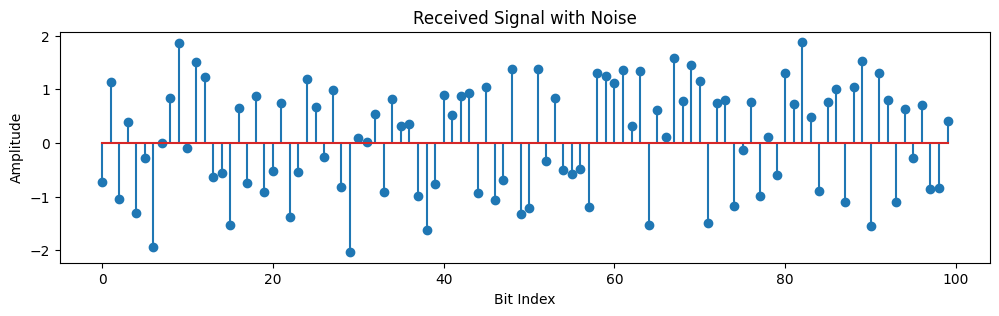

In [6]:
# Noise level
noise_std = 0.5
noise = np.random.normal(0, noise_std, bpsk_signal.shape)

# Noisy signal
rx_signal = bpsk_signal + noise

# Plot noisy signal
plt.figure(figsize=(12,3))
plt.stem(rx_signal)  # Removed use_line_collection
plt.title('Received Signal with Noise')
plt.xlabel('Bit Index')
plt.ylabel('Amplitude')
plt.show()

In [7]:
# Simple threshold at 0
rx_data = (rx_signal > 0).astype(int)
print("Original data: ", data)
print("Received data:", rx_data)

# Bit errors
errors = np.sum(data != rx_data)
print(f"Number of bit errors: {errors} out of {N}")

Original data:  [0 1 0 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 1 0 0 1 0 0 1 1 0 1 0 0 1 0 1 0 1 1 1
 0 0 0 1 1 1 1 0 1 0 0 1 0 0 1 0 1 0 0 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1
 0 0 1 0 1 0 1 1 1 1 0 1 1 0 1 1 0 1 1 0 1 0 1 0 0 1]
Received data: [0 1 0 1 0 0 0 0 1 1 0 1 1 0 0 0 1 0 1 0 0 1 0 0 1 1 0 1 0 0 1 1 1 0 1 1 1
 0 0 0 1 1 1 1 0 1 0 0 1 0 0 1 0 1 0 0 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1
 0 0 1 0 1 0 1 1 1 1 0 1 1 0 1 1 0 1 1 0 1 0 1 0 0 1]
Number of bit errors: 2 out of 100


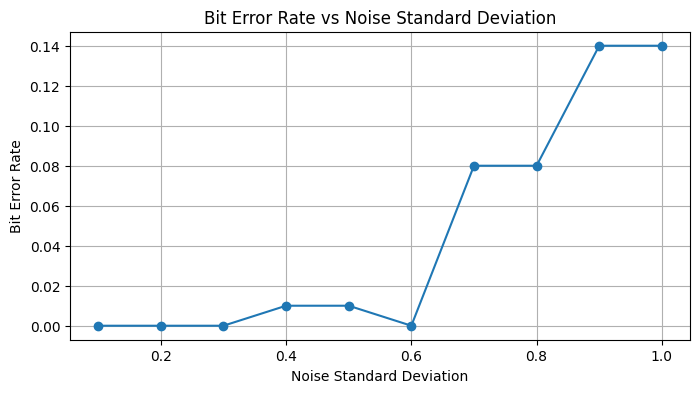

In [8]:
noise_levels = np.linspace(0.1, 1.0, 10)
ber = []

for nl in noise_levels:
    rx_signal = bpsk_signal + np.random.normal(0, nl, bpsk_signal.shape)
    rx_data = (rx_signal > 0).astype(int)
    errors = np.sum(data != rx_data)
    ber.append(errors/N)

plt.figure(figsize=(8,4))
plt.plot(noise_levels, ber, marker='o')
plt.title('Bit Error Rate vs Noise Standard Deviation')
plt.xlabel('Noise Standard Deviation')
plt.ylabel('Bit Error Rate')
plt.grid(True)
plt.show()